Agent 1: MC control on policy

The first agent uses first‑visit Monte Carlo control to learn an action‑value function 
Q
(
s
,
a
)
directly from complete episodes. At each episode, the agent follows an ε‑greedy policy derived from the current 
Q
, collecting a trajectory of 
(
s
,
a
,
r
)
until termination. The return 
G
t
is computed by traversing rewards backward, and for each first visit of a state‑action pair, the average return is updated. The policy is then made ε‑soft by choosing the greedy action with probability 
1
−
ϵ
and exploring otherwise. This approach is model‑free, does not bootstrap (pure Monte Carlo), and optimizes for survival time since the reward is +1 at each step.

Episode   100 | avg length   8.08 | epsilon 0.0732
Episode   200 | avg length  14.81 | epsilon 0.0500
Eval @   200 | greedy avg return  20.40
Episode   300 | avg length  18.16 | epsilon 0.0500
Episode   400 | avg length  21.46 | epsilon 0.0500
Eval @   400 | greedy avg return  24.15
Episode   500 | avg length  21.69 | epsilon 0.0500
Episode   600 | avg length  23.99 | epsilon 0.0500
Eval @   600 | greedy avg return  29.45
Episode   700 | avg length  31.91 | epsilon 0.0500
Episode   800 | avg length  43.75 | epsilon 0.0500
Eval @   800 | greedy avg return  88.65
Episode   900 | avg length  73.73 | epsilon 0.0500
Episode  1000 | avg length  96.90 | epsilon 0.0500
Eval @  1000 | greedy avg return 5023.95
Episode  1100 | avg length 146.74 | epsilon 0.0500
Episode  1200 | avg length 150.03 | epsilon 0.0500
Eval @  1200 | greedy avg return 2021.00
Episode  1300 | avg length 173.65 | epsilon 0.0500
Episode  1400 | avg length 165.36 | epsilon 0.0500
Eval @  1400 | greedy avg return 2880.00
Epi

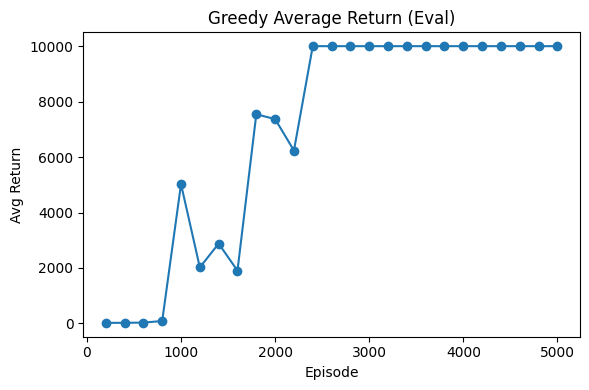

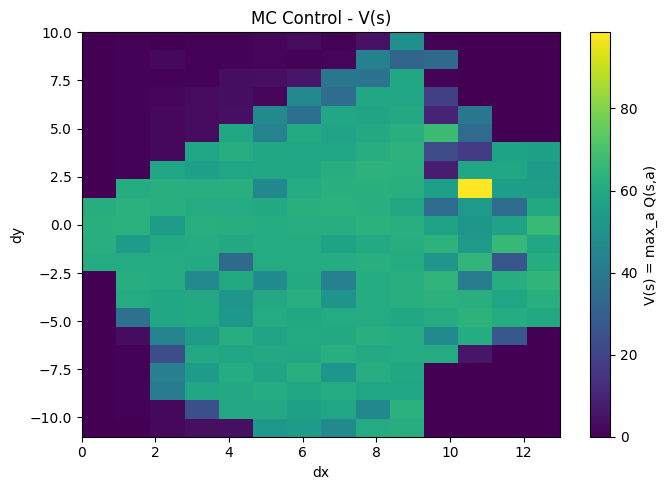

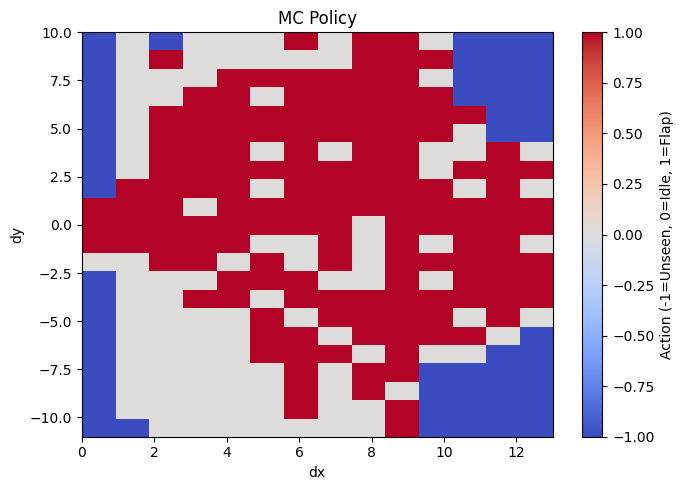

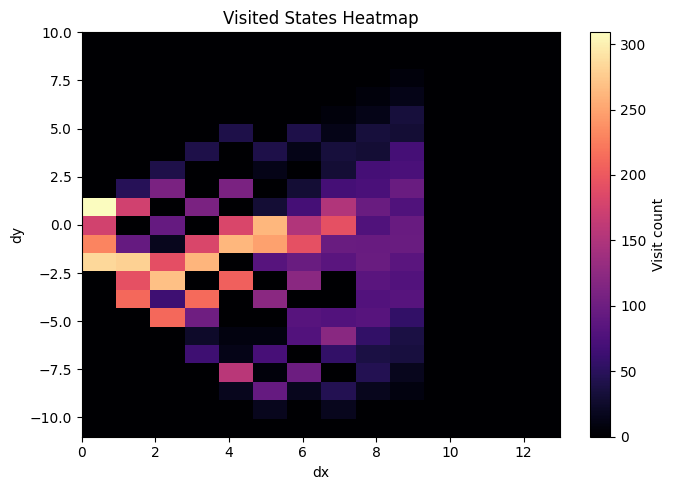

 mean Returns: 10000.0


In [155]:
import os, sys
import numpy as np
import importlib
sys.path.append(os.path.join(os.getcwd(), "env"))
import env.train_mc_control_on_policy
import env.text_flappy_bird_env_simple

importlib.reload(env.train_mc_control_on_policy)
importlib.reload(env.text_flappy_bird_env_simple)

from env.text_flappy_bird_env_simple import TextFlappyBirdEnvSimple
from env.train_mc_control_on_policy import train, run_greedy_agent, plot_value_heatmap, plot_policy_heatmap

env = TextFlappyBirdEnvSimple()

results = train(
    env=env,
    episodes=5000,
    epsilon=0.2,
    epsilon_decay=0.99,
    eval_every=200,
    eval_episodes=20,
)

Q = results["Q"]

plot_value_heatmap(env, Q, title="MC Control - V(s)")
plot_policy_heatmap(env, Q, title="MC Policy")
returns = run_greedy_agent(env, Q, episodes=1, render=False)
print(" mean Returns:", np.mean(returns))





We can see that the greedy average return is increasing during training, then stopping to the maximum value possible. which means the training works well and is stable ! 

The heatmap of the value function is quite what we expected. the bird has to be centered to the pipes gap.

Agent 2 Sarsa(lambda)

Episode   100 | avg length  18.81 | epsilon 0.1810
Episode   200 | avg length  24.85 | epsilon 0.1637
Eval @   200 | greedy avg return 10000.00
Episode   300 | avg length  26.74 | epsilon 0.1481
Episode   400 | avg length  30.34 | epsilon 0.1340
Eval @   400 | greedy avg return 218.15
Episode   500 | avg length  26.70 | epsilon 0.1213
Episode   600 | avg length  35.64 | epsilon 0.1097
Eval @   600 | greedy avg return  28.00
Episode   700 | avg length  35.98 | epsilon 0.0993
Episode   800 | avg length  40.34 | epsilon 0.0898
Eval @   800 | greedy avg return  51.50
Episode   900 | avg length  39.25 | epsilon 0.0813
Episode  1000 | avg length  37.03 | epsilon 0.0735
Eval @  1000 | greedy avg return 172.30
Episode  1100 | avg length  23.15 | epsilon 0.0665
Episode  1200 | avg length  37.42 | epsilon 0.0602
Eval @  1200 | greedy avg return  12.45
Episode  1300 | avg length  29.20 | epsilon 0.0545
Episode  1400 | avg length  32.09 | epsilon 0.0500
Eval @  1400 | greedy avg return 10000.00
Ep

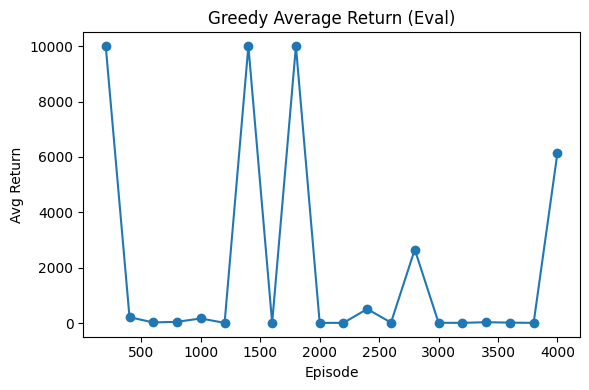

Best weights: [ 11.57825263   0.30446487 -25.81436936  12.36430835  -8.10422298
 -20.41652768  18.95391659   6.88234981  -7.76026755  -3.04440008
  -6.81059044 -24.21947528]


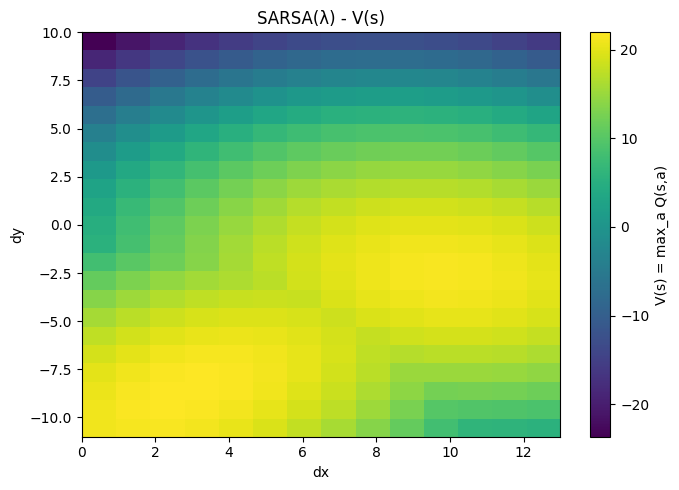

In [ ]:
import os, sys
sys.path.append(os.path.join(os.getcwd(), "env"))
import env.train_sarsa_lambda_true_online
importlib.reload(env.train_sarsa_lambda_true_online)

from env.text_flappy_bird_env_simple import TextFlappyBirdEnvSimple
from env.train_sarsa_lambda_true_online import train, run_greedy_agent, plot_value_heatmap   

env = TextFlappyBirdEnvSimple()

results = train(
    env=env,
    episodes=4000,
    alpha=0.1,
    gamma=0.99,
    lambda_=0.9,
    epsilon=0.2,
    epsilon_decay=0.999,
    epsilon_min=0.05,
    eval_every=200,
)

w_best = results["best_w"]
print("Best weights:", w_best)
plot_value_heatmap(env, w_best, title="SARSA(λ) - V(s)")



The evaluation curve alternates between very high returns (reaching the max‑steps cap) and low returns, indicating that the policy sometimes converges to a strong solution but can later drift as exploration and weight updates continue. In order to have a good agent we chose to keep the best agent during trainig. 

The value function of this agent is significantly different from that of Agent 1. This can be explained by the use of linear function approximation in the second agent.

Indeed, the Q-values are represented as a linear function of the features, which naturally leads to a smoother heatmap compared to the tabular representation used by Agent 1.

Moreover, the highest values are often associated with states that are rarely (or never) visited, as shown in the next plot. This occurs because the function approximator generalizes across the state space and can assign large values to regions with little or no data.

However, high Q-values in such states do not necessarily imply that the agent will actually visit them. The policy is driven by the states encountered during interaction with the environment, so these overestimated values may have little practical impact if those states are unlikely to be reached.



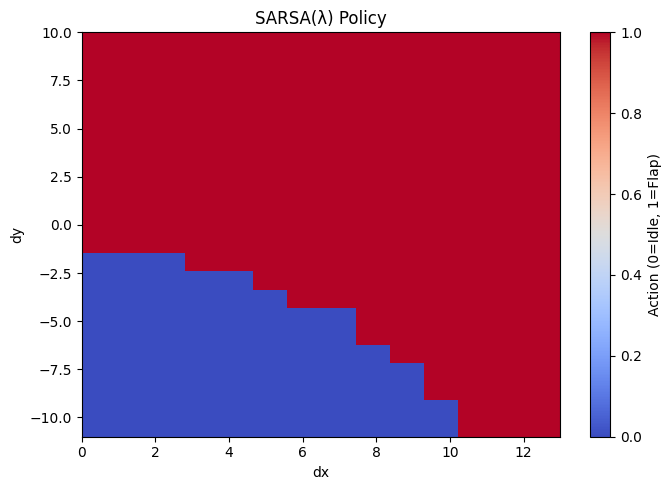

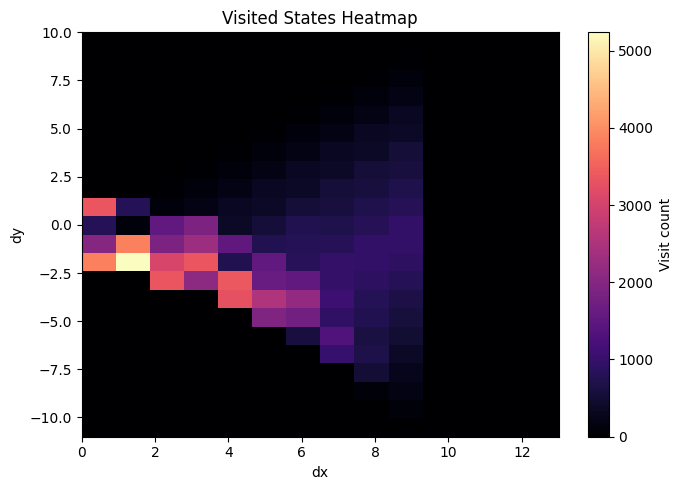

 mean Returns: 10000.0


In [159]:
import env.train_sarsa_lambda_true_online
importlib.reload(env.train_sarsa_lambda_true_online)
from env.train_sarsa_lambda_true_online import plot_policy_heatmap as plot_policy_sarsa

env = TextFlappyBirdEnvSimple()
plot_policy_sarsa(env, w_best, title="SARSA(λ) Policy")


import numpy as np

returns = run_greedy_agent(env, w_best, episodes=10, render=False)
print(" mean Returns:", np.mean(returns))






Experimental Setup
We train and evaluate two reinforcement learning agents on the same text‑based Flappy Bird Gym environment (TextFlappyBirdEnvSimple). The observation is a discrete state (dx, dy) representing horizontal and vertical distance to the center of the next pipe gap. The reward is +1 per step while the bird is alive, so the episode return equals survival time. Training and evaluation are capped at max_steps=10000. During training, we log the greedy average return every 200 episodes and optionally plot learning curves and value maps.

Agent 1: Monte Carlo Control (On‑Policy, ε‑soft)

Method: First‑visit Monte Carlo control.
Policy: ε‑greedy (ε decays over time).
Value Representation: Tabular Q(s,a) stored in a dictionary.
Update: Uses full‑episode returns (no bootstrapping).
Strengths: Stable updates, straightforward to interpret, less sensitive to step size.
Weaknesses: Slower convergence because it needs complete episodes to update.
File: env/train_mc_control_on_policy.py.


Agent 2: True Online SARSA(λ) with Linear Approximation

Method: True Online SARSA(λ).
Policy: ε‑greedy (ε decays over time).
Value Representation: Linear function q(s,a) = wᵀx(s,a) with compact polynomial features; action‑dependent feature blocks.
Update: Bootstrapped TD updates with eligibility traces.
Strengths: Faster learning and generalization across nearby states.
Weaknesses: More sensitive to hyperparameters (α, λ, ε); can oscillate after reaching good performance.
Best Policy Tracking: Keeps the best policy snapshot during training (best_w).
File: env/train_sarsa_lambda_true_online.py.
Key Differences (Sensitivity, Convergence, Rewards/Scores)

Sensitivity to parameters:
SARSA(λ) is more sensitive to α and λ (too high can cause instability). MC is more forgiving but slower.
Convergence time:
SARSA(λ) often reaches high performance sooner, but can regress due to continued exploration. MC converges more slowly but tends to be smoother.
Rewards / scores:
Both optimize survival time (sum of +1 rewards). SARSA can hit the max‑steps cap quickly but may oscillate; MC typically improves steadily.

MC avg return small window: 10000.0
SARSA avg return small window: 239.8
MC avg return large window: 4.0
SARSA avg return large window: 23.5
MC avg return small gap: 24.58
SARSA avg return small gap: 24.3


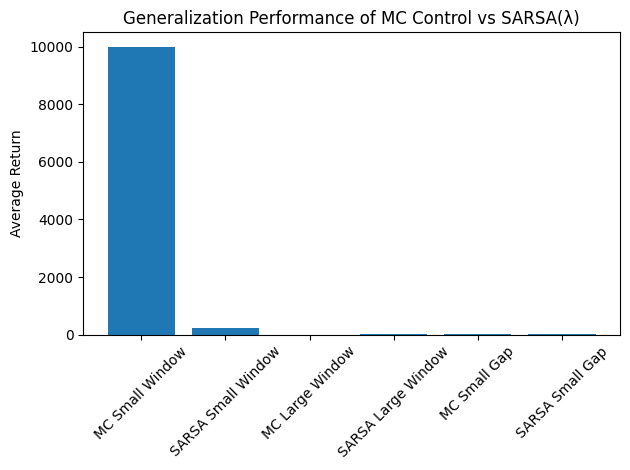

In [ ]:
import matplotlib.pyplot as plt
import env.train_mc_control_on_policy
import env.train_sarsa_lambda_true_online

importlib.reload(env.train_mc_control_on_policy)
importlib.reload(env.train_sarsa_lambda_true_online)

from env.train_mc_control_on_policy import evaluate_on_config as eval_mc
from env.train_sarsa_lambda_true_online import evaluate_on_config as eval_sarsa

score_mc_small_window = eval_mc(Q, height=10, width=15, pipe_gap=4, episodes=100)
score_sarsa_small_window = eval_sarsa(w_best, height=10, width=15, pipe_gap=4, episodes=20)

print("MC avg return small window:", score_mc_small_window)
print("SARSA avg return small window:", score_sarsa_small_window)


score_mc_large_window = eval_mc(Q, height=20, width=25, pipe_gap=4, episodes=100)
score_sarsa_large_window = eval_sarsa(w_best, height=20, width=25, pipe_gap=4, episodes=20)

print("MC avg return large window:", score_mc_large_window)
print("SARSA avg return large window:", score_sarsa_large_window)

score_mc_small_gap = eval_mc(Q, height=15, width=20, pipe_gap=3, episodes=100)
score_sarsa_small_gap = eval_sarsa(w_best, height=15, width=20, pipe_gap=3, episodes=100)

print("MC avg return small gap:", score_mc_small_gap)
print("SARSA avg return small gap:", score_sarsa_small_gap)

plt.bar(["MC Small Window", "SARSA Small Window", "MC Large Window", "SARSA Large Window", "MC Small Gap", "SARSA Small Gap"],
        [score_mc_small_window, score_sarsa_small_window, score_mc_large_window, score_sarsa_large_window, score_mc_small_gap, score_sarsa_small_gap])
plt.ylabel("Average Return")
plt.title("Generalization Performance of MC Control vs SARSA(λ)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




Some of these results are expected. With a larger observation window, tabular methods become inefficient because the state space grows significantly. As a result, when the agent encounters a previously unseen state, it has no prior information to guide its action.

In contrast, the SARSA agent uses linear function approximation, which allows it to generalize across states. Even when facing unseen states, it can rely on similarities with previously encountered ones and thus behave more consistently.

However, it is more difficult to explain why the SARSA agent performs poorly with a smaller window. One possible explanation is that the learned state representation (or value function) becomes less informative or less stable in this setting.

Finally, when the pipe gap is smaller, both agents perform poorly. This is likely due to the reward structure: during training, there is no incentive to pass through the center of the gap. As a result, the agents do not learn to optimize their trajectory with respect to the middle of the pipe, which becomes critical when the gap is reduced.
